# CT / MR simulators

In this notebook we will build some "toy simulators" for CT and MR scanners, which will be used in the next "denoising" experiences.
Here you will familiarize with how they work and some image quality metrics

In [24]:
%matplotlib inline
import skimage.data
import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
from skimage.transform import radon, iradon, resize


# Task 1: Tomographic image simulator

CT images are reconstructed (at least in the basic version) using the Radon transform and its inverse. In python, the skimage library provides these transforms already implemented
(skimage.transform.radon for the transform, skimage.transform.iradon for the inverse)

Use these functions to build a "CT simulator".

Take as input image the "shepp-logan" phantom (from skimage.data import shepp_logan_phantom, which is a function that takes no input and returns a 400x400 image).

Resample it to lower resolution using skimage.transform.resize to the shape you want (e.g. 128x128). Do you like the output? If not, read the help and think about the anti_aliasing parameter setting. This will be your test image for the next experiences.

To simulate the CT scan, create a function that takes in input the test image, transforms it in sinogram space using a vector of projection angles, adds gaussian noise to it (standard deviation as input) and then reconstruct the image using iradon. In both radon and iradon functions, set the flag "circle" to False (it changes the behaviour for padding the borders)

Initially, in this simulator, have the function display a figure with 2 subplot, the original sinogram with no noise and the sinogram with noise added

First, do the reconstruction with no noise (and display it). Remember that sampling from 0 to 180 degrees is sufficient. But how many "steps" in between do you need? Does this depend on the number of pixels you used in input? Try that!!

Then try different values of noise and see how much higher can you go with noise and still see the output


In [25]:
class CTSimulator:
    def __init__(self, image: np.ndarray) -> None:
        self.image = image

    def show_image(self):
        plt.figure(figsize=(6, 6))
        plt.imshow(self.image)

    def resample(
        self, shape: tuple[int, int], anti_aliasing: bool = True
    ) -> np.ndarray:
        return resize(self.image, shape, anti_aliasing=anti_aliasing)

    def radon_transform(
        self,
        std_noise: float | int,
        projection_angles: np.ndarray | None = None,
    ) -> np.ndarray:
        if projection_angles is None:
            projection_angles = np.arange(0, 180, 1)

        sinogram = radon(self.image, theta=projection_angles, circle=False)
        noise = np.random.normal(0, std_noise, sinogram.shape)
        return sinogram + noise
    
    def radon_inverse_transform(
            self,
            sinogram: np.ndarray,
            projection_angles: np.ndarray | None = None,
    ) -> np.ndarray:
        if projection_angles is None:
            projection_angles = np.arange(0, 180, 1)

        return iradon(sinogram, theta=projection_angles, circle=False)


Text(0.5, 1.0, 'Resized Image')

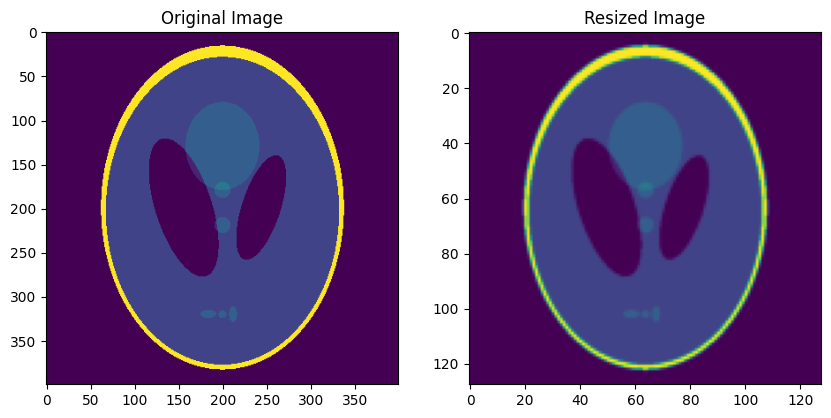

In [26]:
img = skimage.data.shepp_logan_phantom()

ct_simulator = CTSimulator(img)
resized_img = ct_simulator.resample((128, 128))

# Plot both images into two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img)

ax1.set_title("Original Image")

ax2.imshow(resized_img)
ax2.set_title("Resized Image")

Text(0.5, 1.0, 'With Noise')

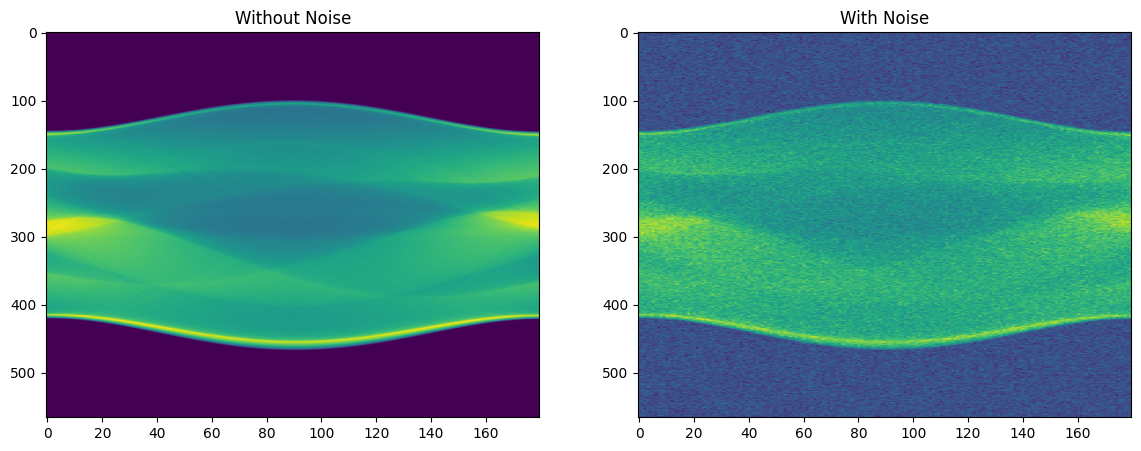

In [27]:
sinogram = ct_simulator.radon_transform(0, np.arange(0, 180, 1))
noisy_sinogram = ct_simulator.radon_transform(10, np.arange(0, 180, 1))

# Show 2 subplots, with noise and without noise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(sinogram, aspect="auto")
ax1.set_title("Without Noise")

ax2.imshow(noisy_sinogram, aspect="auto")
ax2.set_title("With Noise")

Text(0.5, 1.0, 'Reconstructed Image with Noise')

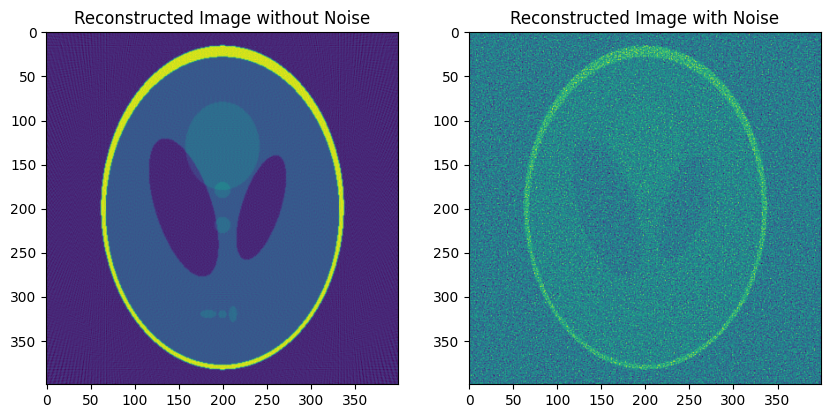

In [28]:
# Reconstruct the original image using the inverse radon transform
reconstruction = ct_simulator.radon_inverse_transform(sinogram, projection_angles=np.arange(0, 180, 1))

# Reconstruct the noisy image using the inverse radon transform
noisy_reconstruction = ct_simulator.radon_inverse_transform(noisy_sinogram, projection_angles=np.arange(0, 180, 1))

# Plot both reconstructed images into two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(reconstruction)
ax1.set_title("Reconstructed Image without Noise")
ax2.imshow(noisy_reconstruction)
ax2.set_title("Reconstructed Image with Noise")

## Assesment:

1. Do you understand what the sinogram is showing you?
2. Does the sinogram seems noisy with the noise level you chose?
3. Is the reconstructed image noisy when you have a sinogram that doesn't look noisy?
4. Does the concept of "noisy" depend on what you are looking at?

# Task 2: Compute noise Metrics with respect to the true image

1. compute the MSE (should be easy)
2. Compute the PSNR (which is the "dynamic range"?). Can also be computed with skimage.metrics.peak_signal_noise_ration
3. Compute the SSIM. Can be done using skimage.metrics.structural_similarity

In [45]:
mse = np.mean(((img - reconstruction)**2))

noisy_mse = np.mean(((img - noisy_reconstruction)**2))

print("MSE without noise: ", mse)
print("MSE with noise:    ", noisy_mse)


MSE without noise:  0.0013843223027618394
MSE with noise:     0.21737095938169224


In [55]:
data_range = np.max(img) - np.min(img)

In [60]:
PSNR = skimage.metrics.peak_signal_noise_ratio(img,reconstruction,data_range=data_range)
PSNR_noisy = skimage.metrics.peak_signal_noise_ratio(img,noisy_reconstruction,data_range=data_range)

print("PSNR without noise: ", PSNR)
print("PSNR with noise:    ", PSNR_noisy)

PSNR without noise:  28.587627841458435
PSNR with noise:     6.627984778335979


In [63]:
SSIM = skimage.metrics.structural_similarity(img, reconstruction, gaussian_weights=False, data_range=data_range)
SSIM_noisy = skimage.metrics.structural_similarity(img, noisy_reconstruction, gaussian_weights=False, data_range=data_range)

print("SSIM without noise: ", SSIM)
print("SSIM with noise:    ", SSIM_noisy)

SSIM without noise:  0.6897304720535934
SSIM with noise:     0.04261004636665211


Think about the image. You can display different features selecting a different intensity window (e.g. 0.2-0.4) to see best the inner "circles". Does the image still look like it has the same noise as displayed with the full range?

If not recompute the SSIM taking this into account

Text(0.5, 1.0, 'Windowed [0.2, 0.4]')

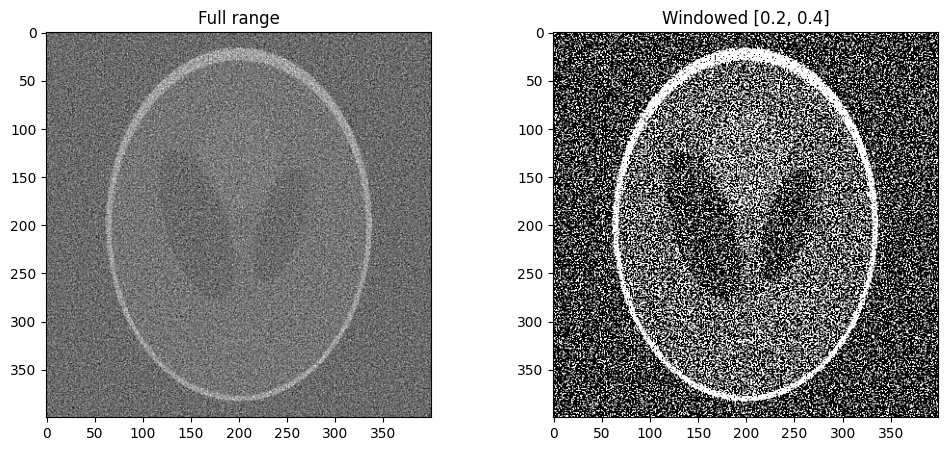

In [75]:
# Try it:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(noisy_reconstruction, cmap="gray")
ax1.set_title("Full range")
ax2.imshow(noisy_reconstruction, cmap="gray", vmin=0.2, vmax=0.4)
ax2.set_title("Windowed [0.2, 0.4]")

In [76]:
window_low, window_high = 0.2, 0.4
window_range = window_high - window_low  # 0.2

SSIM_windowed = skimage.metrics.structural_similarity(
    img, noisy_reconstruction,
    data_range=window_range,
    gaussian_weights=True, sigma=1.5,
)

print(SSIM_windowed)

0.031180840810715153


# Task 3: apply metrics to a number of conditions

1. Make a plot of MSE, PSNR, SSIM as a function of the noise parameter in the "CT simulator function"
2. For one value of noise level, plot the SSIM as a function of the number of angles used assuming "same radiation dose" (i.e.: if you halve the n° of angles, reduce the noise by sqrt(2)). Use n° of angles from very low to more than necessary: e.g. (5,10,20,40,80,160,320)

BTW, why square root?

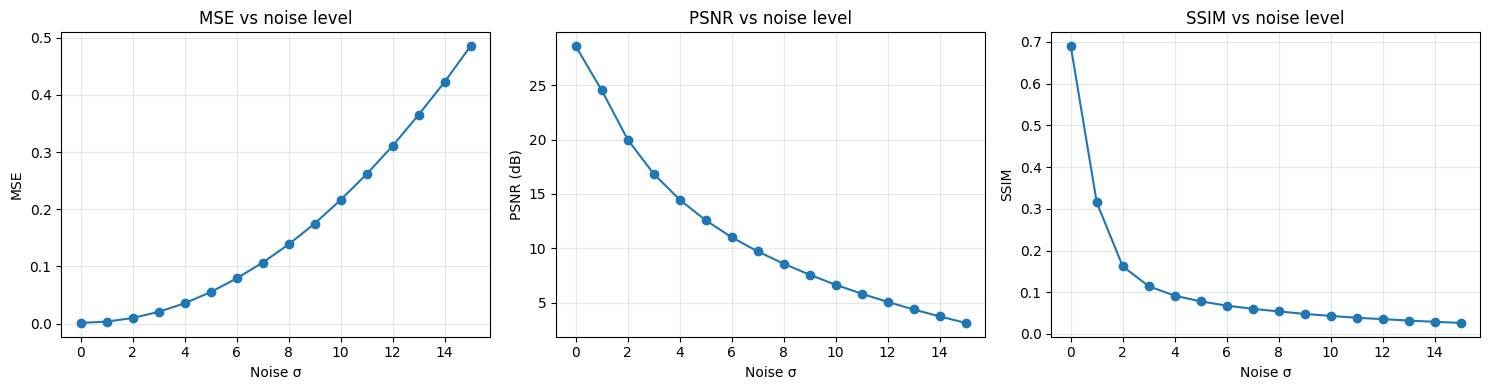

In [ ]:
noise_levels = np.arange(0, 16, 1)   # σ = 0, 1, 2, ..., 15
n_realizations = 5                   # average over several noise draws per σ

mse_values, psnr_values, ssim_values = [], [], []

for sigma in noise_levels:
    mse_runs, psnr_runs, ssim_runs = [], [], []
    for _ in range(n_realizations):
        sinogram = ct_simulator.radon_transform(std_noise=sigma)
        recon    = ct_simulator.radon_inverse_transform(sinogram)

        mse_runs.append(np.mean((img - recon) ** 2))
        psnr_runs.append(skimage.metrics.peak_signal_noise_ratio(
            img, recon, data_range=data_range))
        ssim_runs.append(skimage.metrics.structural_similarity(
            img, recon, data_range=data_range))

    mse_values.append(np.mean(mse_runs))
    psnr_values.append(np.mean(psnr_runs))
    ssim_values.append(np.mean(ssim_runs))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(noise_levels, mse_values, "o-")
axes[0].set(xlabel="Noise σ", ylabel="MSE", title="MSE vs noise level")

axes[1].plot(noise_levels, psnr_values, "o-")
axes[1].set(xlabel="Noise σ", ylabel="PSNR (dB)", title="PSNR vs noise level")

axes[2].plot(noise_levels, ssim_values, "o-")
axes[2].set(xlabel="Noise σ", ylabel="SSIM", title="SSIM vs noise level")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

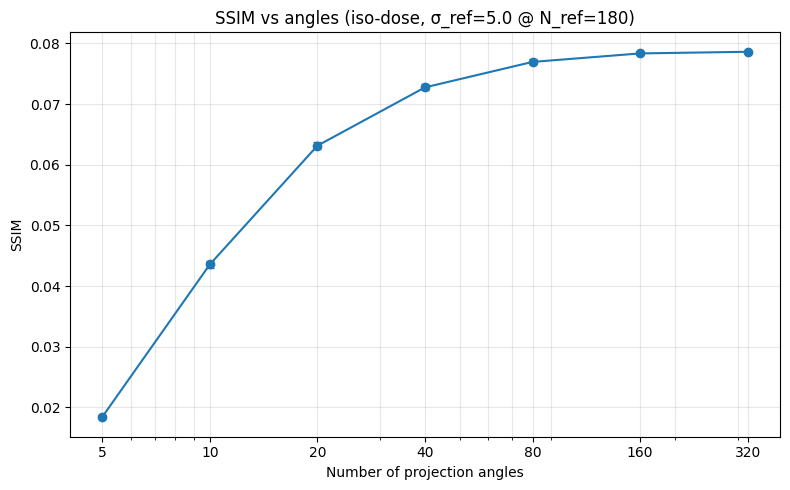

In [79]:
# --- iso-dose reference point ---
N_ref     = 180
sigma_ref = 5.0     # pick whatever moderate noise level you want as reference

n_angles_list  = [5, 10, 20, 40, 80, 160, 320]
n_realizations = 5
data_range     = img.max() - img.min()

ssim_means, ssim_stds = [], []

for N in n_angles_list:
    sigma_N = sigma_ref * np.sqrt(N / N_ref)   # iso-dose scaling
    angles  = np.linspace(0, 180, N, endpoint=False)

    runs = []
    for _ in range(n_realizations):
        sinogram = ct_simulator.radon_transform(
            std_noise=sigma_N, projection_angles=angles
        )
        recon = ct_simulator.radon_inverse_transform(
            sinogram, projection_angles=angles
        )
        runs.append(skimage.metrics.structural_similarity(
            img, recon, data_range=data_range
        ))
    ssim_means.append(np.mean(runs))
    ssim_stds.append(np.std(runs))

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(n_angles_list, ssim_means, yerr=ssim_stds,
            fmt="o-", capsize=3)
ax.set_xscale("log")
ax.set_xlabel("Number of projection angles")
ax.set_ylabel("SSIM")
ax.set_title(f"SSIM vs angles (iso-dose, σ_ref={sigma_ref} @ N_ref={N_ref})")
ax.grid(True, which="both", alpha=0.3)
ax.set_xticks(n_angles_list)
ax.set_xticklabels(n_angles_list)
plt.tight_layout()
plt.show()

# Task 4: Compute noise properties of reconstructed images

Over a large number of noise realizations (how many are needed?? Start low and see) reconstruct the image and save it. Then

1. Compute the mean. What do you expect/find  and how does it compare to the reference image?
2. Compute the standard deviation over the noise realizations
3. Compute the noise power spectrum: it is defined as the average of the square of the fourier transform of every image, subtracting the mean image. Why can't you compute it on one image only? Why does it look this way?
5. Save this NPS in a matrix and plot the zero row and column. How do they look? Is this what you expect?
4. If in iradon you pass a filter parameter, how does the NPS change?


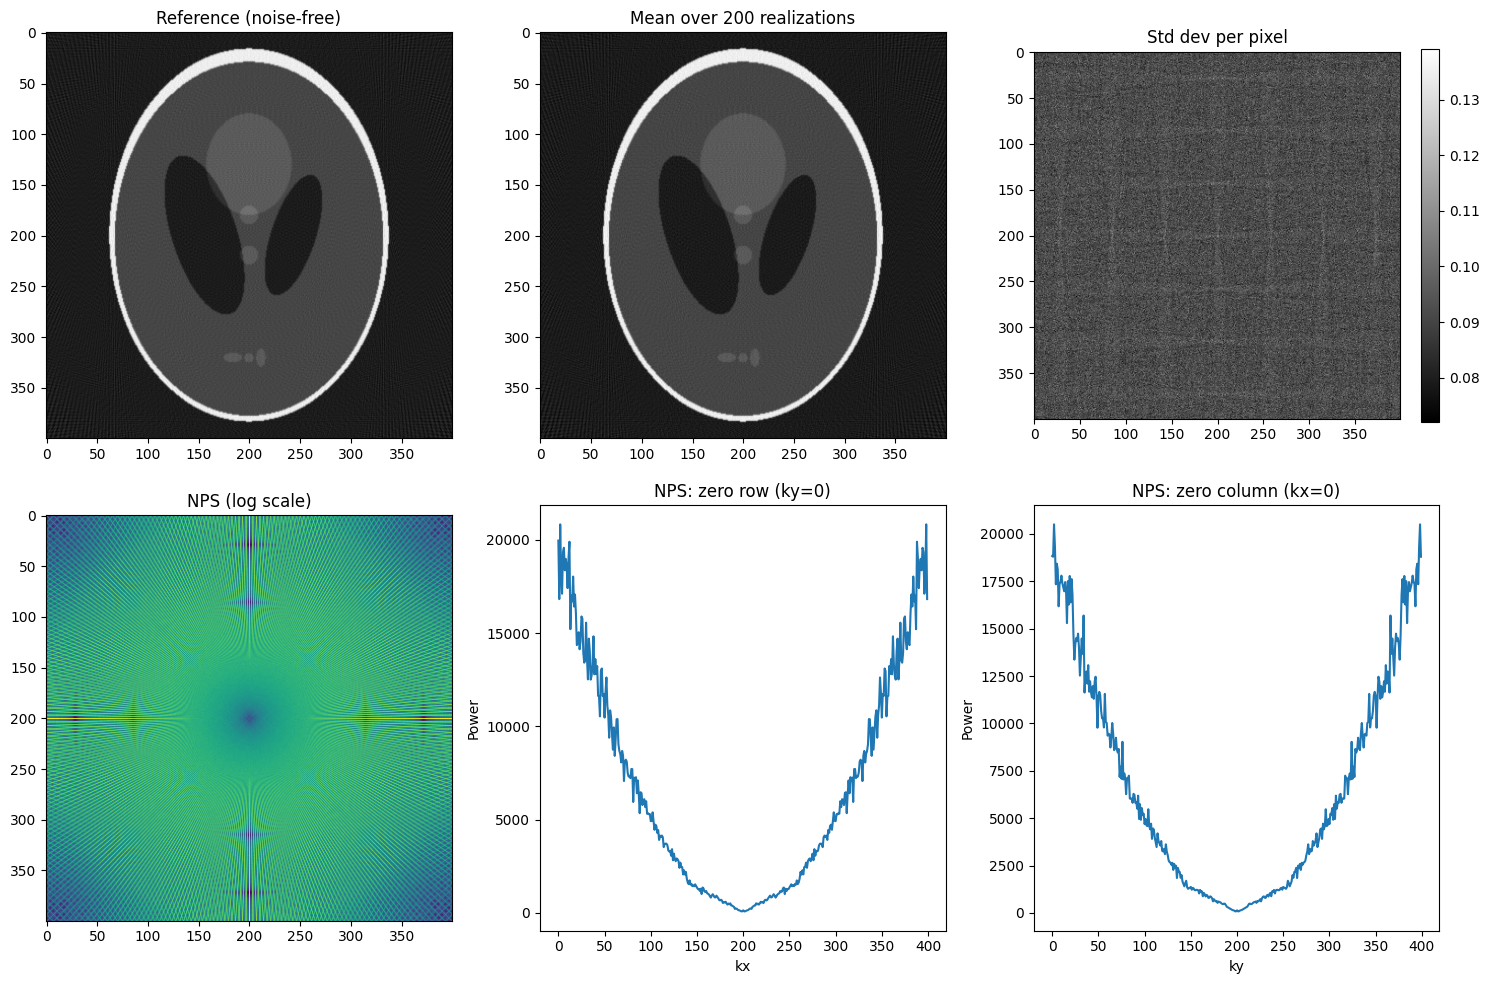

In [ ]:

# --- setup ---
N_realizations = 200        # start with ~50, see if estimates stabilize, increase as needed
sigma          = 2.0
angles         = np.arange(0, 180, 1)

# clean reference reconstruction (no noise)
clean_sinogram = radon(img, theta=angles, circle=False)
reference_recon = iradon(clean_sinogram, theta=angles, circle=False)

# --- generate many noisy reconstructions ---
reconstructions = np.zeros((N_realizations, *reference_recon.shape))
for i in range(N_realizations):
    noisy_sino = clean_sinogram + np.random.normal(0, sigma, clean_sinogram.shape)
    reconstructions[i] = iradon(noisy_sino, theta=angles, circle=False)

# --- 1. mean image ---
mean_image = reconstructions.mean(axis=0)

# --- 2. per-pixel standard deviation ---
std_image = reconstructions.std(axis=0)

# --- 3. Noise Power Spectrum ---
noise_only = reconstructions - mean_image            # subtract the mean — that's the "signal"
fft_noise  = np.fft.fftshift(np.fft.fft2(noise_only), axes=(-2, -1))
nps = np.mean(np.abs(fft_noise) ** 2, axis=0)

# --- plot everything ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(reference_recon, cmap="gray")
axes[0, 0].set_title("Reference (noise-free)")

axes[0, 1].imshow(mean_image, cmap="gray")
axes[0, 1].set_title(f"Mean over {N_realizations} realizations")

axes[0, 2].imshow(std_image, cmap="gray")
axes[0, 2].set_title("Std dev per pixel")
plt.colorbar(axes[0, 2].images[0], ax=axes[0, 2], fraction=0.046)

# NPS displayed on log scale — dynamic range is huge
axes[1, 0].imshow(np.log1p(nps), cmap="viridis")
axes[1, 0].set_title("NPS (log scale)")

# central row and column (zero-frequency lines)
cy, cx = nps.shape[0] // 2, nps.shape[1] // 2
axes[1, 1].plot(nps[cy, :])
axes[1, 1].set_title("NPS: zero row (ky=0)")
axes[1, 1].set_xlabel("kx"); axes[1, 1].set_ylabel("Power")

axes[1, 2].plot(nps[:, cx])
axes[1, 2].set_title("NPS: zero column (kx=0)")
axes[1, 2].set_xlabel("ky"); axes[1, 2].set_ylabel("Power")

plt.tight_layout()
plt.show()

# Task 5: MR image simulator

Now do the same for MR. The MR coils acquire the 2D fourier transform of a signal and there (mostly) gaussian noise is present. Therefore you need to do
signal = np.fft.fft2 (input image), signal+=noise, image = np.real(np.fft.ifft2(signal))

Compute the same metrics as before. Do not experiment (for now....) with the number of points acquired in the FT space.

How do you expect the NPS to look like in MR?

In [82]:
class MRSimulator:
    def __init__(self, image: np.ndarray) -> None:
        self.image = image

    def show_image(self) -> None:
        plt.figure(figsize=(6, 6))
        plt.imshow(self.image, cmap="gray")
        plt.axis("off")

    def acquire(self, std_noise: float) -> np.ndarray:
        """Simulate MR acquisition: add complex Gaussian noise in k-space."""
        signal = np.fft.fft2(self.image)
        noise = (np.random.normal(0, std_noise, signal.shape)
                 + 1j * np.random.normal(0, std_noise, signal.shape))
        signal = signal + noise
        return np.real(np.fft.ifft2(signal))

MSE=0.0006  PSNR=32.04 dB  SSIM=0.615


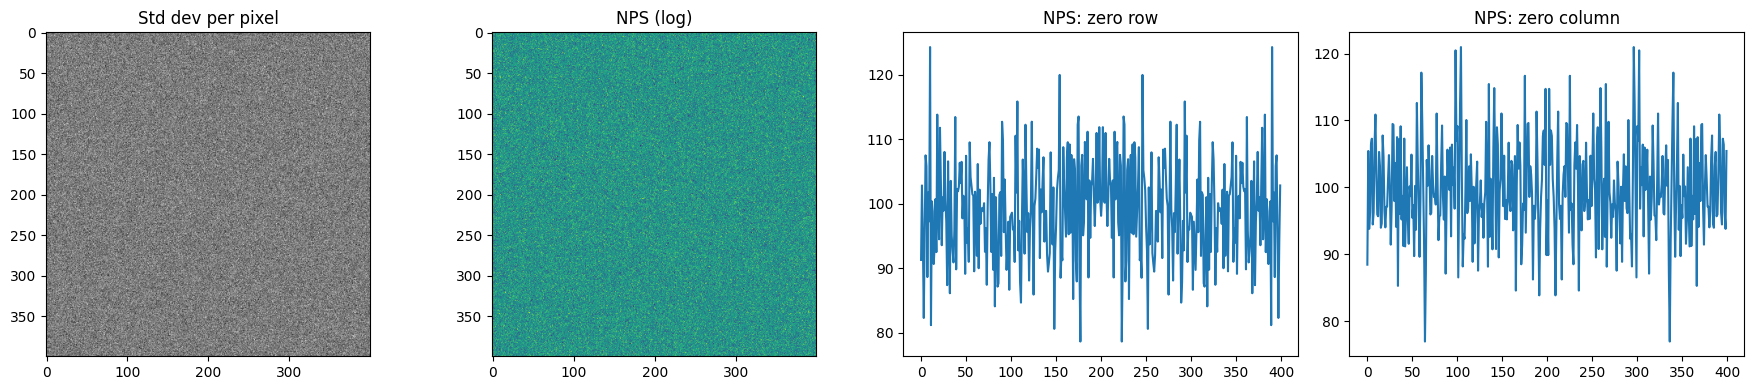

In [83]:
mr_sim = MRSimulator(img)

# Same structure as the CT task
N_realizations = 200
sigma = 10.0     # pick a reasonable k-space noise level

# Reference (noise-free)
reference = np.real(np.fft.ifft2(np.fft.fft2(img)))   # ≈ img up to numerical noise

# Many noisy reconstructions
reconstructions = np.zeros((N_realizations, *img.shape))
for i in range(N_realizations):
    reconstructions[i] = mr_sim.acquire(std_noise=sigma)

mean_image = reconstructions.mean(axis=0)
std_image  = reconstructions.std(axis=0)

noise_only = reconstructions - mean_image
fft_noise  = np.fft.fftshift(np.fft.fft2(noise_only), axes=(-2, -1))
nps_mri    = np.mean(np.abs(fft_noise) ** 2, axis=0)

# MSE / PSNR / SSIM for one sample realization vs reference
sample = reconstructions[0]
data_range = img.max() - img.min()
mse  = np.mean((img - sample) ** 2)
psnr = skimage.metrics.peak_signal_noise_ratio(img, sample, data_range=data_range)
ssim = skimage.metrics.structural_similarity(img, sample, data_range=data_range)
print(f"MSE={mse:.4f}  PSNR={psnr:.2f} dB  SSIM={ssim:.3f}")

# Plot: std image + NPS + zero row/col
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(std_image, cmap="gray");    axes[0].set_title("Std dev per pixel")
axes[1].imshow(np.log1p(nps_mri), cmap="viridis"); axes[1].set_title("NPS (log)")
cy, cx = nps_mri.shape[0] // 2, nps_mri.shape[1] // 2
axes[2].plot(nps_mri[cy, :]); axes[2].set_title("NPS: zero row")
axes[3].plot(nps_mri[:, cx]); axes[3].set_title("NPS: zero column")
plt.tight_layout(); plt.show()